In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [ ]:
df = pd.read_csv("/content/jura_pred.csv")
print(df.shape)
df.head()

(259, 11)


,Xloc,Yloc,Landuse,Rock,Cd,Co,Cr,Cu,Ni,Pb,Zn
0,2.386,3.077,3,3,1.740,9.32,38.32,25.72,21.32,77.36,92.56
1,2.544,1.972,2,2,1.335,10.00,40.20,24.76,29.72,77.88,73.56
2,2.807,3.347,2,3,1.610,10.60,47.00,8.88,21.40,30.80,64.80
3,4.308,1.933,3,2,2.150,11.92,43.52,22.70,29.72,56.40,90.00
4,4.383,1.081,3,5,1.565,16.32,38.52,34.32,26.20,66.40,88.40


##Visualize the data

Before log:
Cd    1.51
Co   -0.18
Cr    0.29
Ni    0.16
Pb    2.91
Zn    1.03
Cu    2.88
dtype: float64

After log:
Cd    0.54
Co   -0.84
Cr   -0.71
Ni   -0.88
Pb    0.89
Zn   -0.17
Cu    0.42
dtype: float64


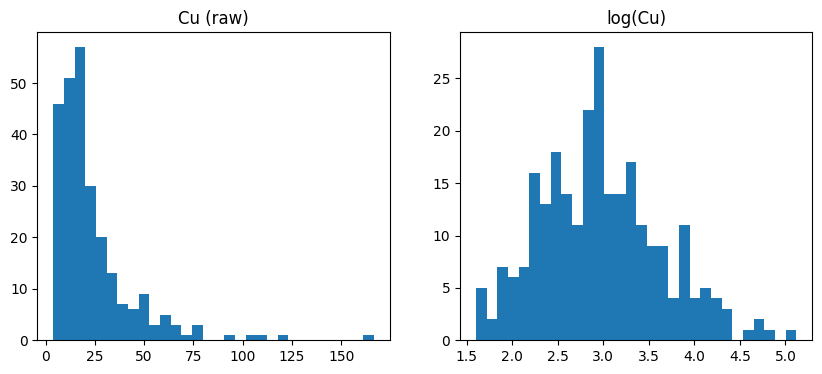

In [ ]:
metals = ['Cd', 'Co', 'Cr', 'Ni', 'Pb', 'Zn']

print('Before log:')
print(df[metals + ['Cu']].skew().round(2))
print()
print('After log:')
print(np.log1p(df[metals + ['Cu']]).skew().round(2))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(df['Cu'], bins=30)
ax[0].set_title('Cu (raw)')
ax[1].hist(np.log1p(df['Cu']), bins=30)
ax[1].set_title('log(Cu)')
plt.show()

##Categorizing the Copper quantities into 3 classes which are low, medium and high.

In [7]:
classes = ['low','medium','high']

df['Cu_class'], bins = pd.qcut(df['Cu'], q=3, labels=classes, retbins=True)

print('Class boundaries (mg/kg):', bins.round(2))
print(df['Cu_class'].value_counts())

Class boundaries (mg/kg): [  3.96  13.12  23.44 166.4 ]
Cu_class
high      87
low       86
medium    86
Name: count, dtype: int64


##Feature Preparation
1. Log-transform the metals
2. Turn Landuse and Rock into 0/1 columns.They are categories not numbers.

In [8]:
X = df[['Xloc', 'Yloc', 'Landuse', 'Rock'] + metals].copy()

for m in metals:
  X[m] = np.log1p(X[m])

X = pd.get_dummies(X, columns=['Landuse', 'Rock'], dtype=int)

y = df['Cu_class']

print(X.columns.tolist())
X.head()

['Xloc', 'Yloc', 'Cd', 'Co', 'Cr', 'Ni', 'Pb', 'Zn', 'Landuse_1', 'Landuse_2', 'Landuse_3', 'Landuse_4', 'Rock_1', 'Rock_2', 'Rock_3', 'Rock_4', 'Rock_5']


,Xloc,Yloc,Cd,Co,Cr,Ni,Pb,Zn,Landuse_1,Landuse_2,Landuse_3,Landuse_4,Rock_1,Rock_2,Rock_3,Rock_4,Rock_5
0,2.386,3.077,1.007958,2.334084,3.671733,3.105483,4.361314,4.538603,0,0,1,0,0,0,1,0,0
1,2.544,1.972,0.848012,2.397895,3.718438,3.424914,4.367928,4.311604,0,1,0,0,0,1,0,0,0
2,2.807,3.347,0.959350,2.451005,3.871201,3.109061,3.459466,4.186620,0,1,0,0,0,0,1,0,0
3,4.308,1.933,1.147402,2.558776,3.795939,3.424914,4.050044,4.510860,0,0,1,0,0,1,0,0,0
4,4.383,1.081,0.941958,2.851862,3.676807,3.303217,4.210645,4.493121,0,0,1,0,0,0,0,0,1


## Train test split


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

models = {
    'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    'Linear SVM':          make_pipeline(StandardScaler(), SVC(kernel='linear')),
    'RBF SVM':             make_pipeline(StandardScaler(), SVC(kernel='rbf', C=3)),
    'Random Forest':       RandomForestClassifier(n_estimators=400, min_samples_leaf=2, random_state=42),

}

for name, model in models.items():
  model.fit(X_train, y_train)
  pred = model.predict(X_test)
  print(f'{name:.20s} accuracy = {accuracy_score(y_test, pred):.3f} F1 = {f1_score(y_test, pred, average='weighted'):.3f}')

Logistic Regression accuracy = 0.827 F1 = 0.826
Linear SVM accuracy = 0.827 F1 = 0.827
RBF SVM accuracy = 0.750 F1 = 0.755
Random Forest accuracy = 0.846 F1 = 0.846


## Cross validation
Random 5-fold: split the data 5 times and average.


Spatial 5-fold: cut the map into 1km squares and hold out whole squares. This is harder and more honest because the model cant cheat by using nearby samples.

In [15]:
blocks = df['Xloc'].astype(int).astype(str) + '_' + df['Yloc'].astype(int).astype(str)
print('Number of 1 km blocks:', blocks.nunique())

random_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
spatial_cv = GroupKFold(n_splits=5)

results = []
for name, model in models.items():
  r = cross_val_score(model, X, y, cv=random_cv)
  s = cross_val_score(model, X, y, cv=spatial_cv, groups=blocks)
  results.append([name, r.mean(), r.std(), s.mean(), s.std()])

results = pd.DataFrame(results, columns=['Model', 'Random CV', '+/- sd', 'Spatial CV', '+/- sd'])
results.round(3)

Number of 1 km blocks: 21


,Model,Random CV,+/- sd,Spatial CV,+/- sd
0,Logistic Regression,0.803,0.019,0.722,0.062
1,Linear SVM,0.815,0.035,0.741,0.067
2,RBF SVM,0.718,0.044,0.694,0.079
3,Random Forest,0.791,0.031,0.729,0.055


Best model is Linear SVM with a higher spatial  Cv score.


In [16]:
best_name  = results.sort_values('Spatial CV', ascending=False)['Model'].iloc[0]
best_model = models[best_name]
print('Best model:', best_name)

Best model: Linear SVM


## Results

              precision    recall  f1-score   support

         low       0.86      0.71      0.77        17
      medium       0.70      0.82      0.76        17
        high       0.94      0.94      0.94        18

    accuracy                           0.83        52
   macro avg       0.83      0.82      0.83        52
weighted avg       0.84      0.83      0.83        52



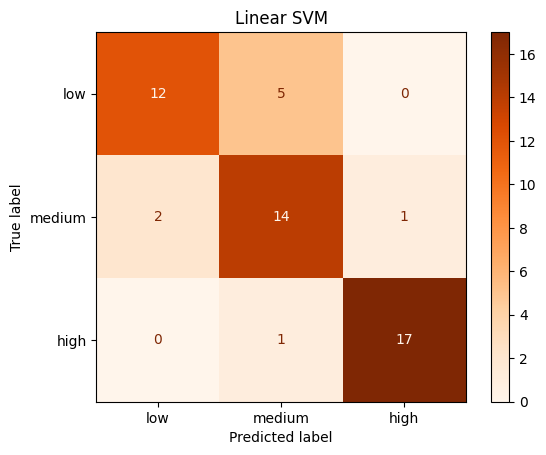

In [17]:
best_model.fit(X_train, y_train)
pred = best_model.predict(X_test)

print(classification_report(y_test, pred, labels=classes))

cm = confusion_matrix(y_test, pred, labels=classes)
ConfusionMatrixDisplay(cm, display_labels=classes).plot(cmap='Oranges')
plt.title(best_name)
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

## Feature importance


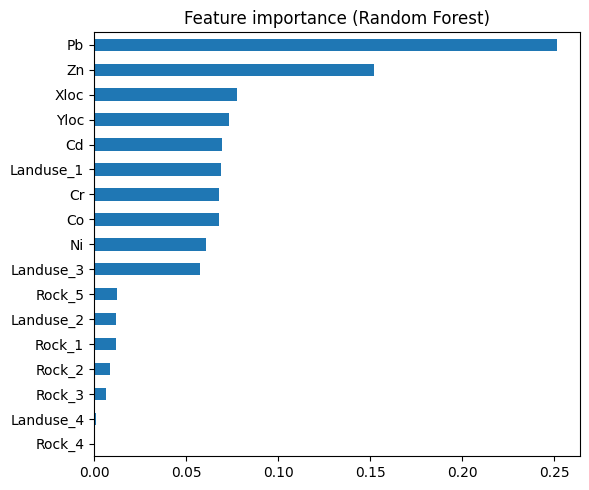

In [18]:
rf = models['Random Forest']
rf.fit(X_train, y_train)

importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
importance.plot.barh(figsize=(6, 5))
plt.title('Feature importance (Random Forest)')
plt.tight_layout()
plt.show()

## Independent Validation

In [20]:
best_model.fit(X, y)

if os.path.exists('/content/jura_val.csv') and 'Cu' in pd.read_csv('/content/jura_val.csv').columns:
  val = pd.read_csv('/content/jura_val.csv')

  y_val = pd.cut(val['Cu'], bins=[-np.inf, bins[1], bins[2], np.inf], labels=classes)

  X_val = val[['Xloc', 'Yloc', 'Landuse', 'Rock'] + metals].copy()
  for m in metals:
    X_val[m] = np.log1p(X_val[m])
  X_val = pd.get_dummies(X_val, columns=['Landuse', 'Rock'], dtype=int)
  X_val = X_val.reindex(columns=X.columns, fill_value=0)

  val_pred = best_model.predict(X_val)
  print('Validation accuracy:', round(accuracy_score(y_val, val_pred), 3))
  print(classification_report(y_val, val_pred, labels=classes))
else:
  print('No validation file with Cu found - skipped.')

Validation accuracy: 0.8
              precision    recall  f1-score   support

         low       0.87      0.77      0.82        44
      medium       0.77      0.74      0.75        31
        high       0.74      0.92      0.82        25

    accuracy                           0.80       100
   macro avg       0.79      0.81      0.80       100
weighted avg       0.81      0.80      0.80       100



## Map of Predicted Cu class

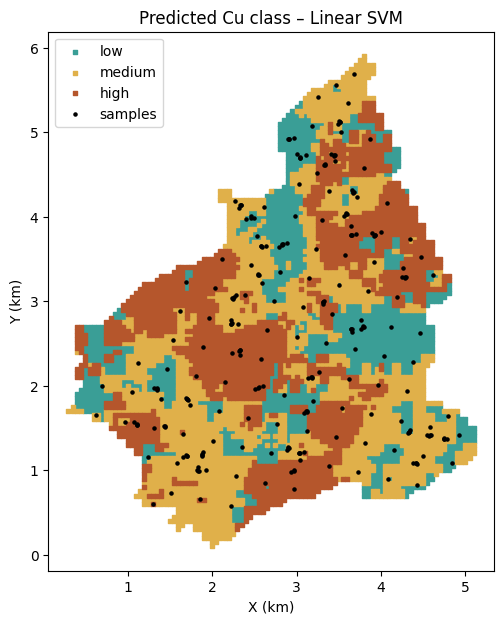

Cu_pred
medium    0.416
high      0.333
low       0.251
Name: proportion, dtype: float64


In [22]:
if os.path.exists('/content/jura_grid.csv'):
    grid = pd.read_csv('/content/jura_grid.csv')

    # if Landuse / Rock are written as words, change them to the same numbers used in jura_pred.csv
    landuse_codes = {'Forest': 1, 'Pasture': 2, 'Meadow': 3, 'Tillage': 4}
    rock_codes = {'Argovian': 1, 'Kimmeridgian': 2, 'Sequanian': 3, 'Portlandian': 4, 'Quaternary': 5}
    if grid['Landuse'].dtype == object:
        grid['Landuse'] = grid['Landuse'].map(landuse_codes)
    if grid['Rock'].dtype == object:
        grid['Rock'] = grid['Rock'].map(rock_codes)

    # estimate each metal on the grid from nearby samples
    for m in metals:
        knn = KNeighborsRegressor(n_neighbors=12, weights='distance')
        knn.fit(df[['Xloc', 'Yloc']], np.log1p(df[m]))
        grid[m] = knn.predict(grid[['Xloc', 'Yloc']])        # already on the log scale

    X_grid = pd.get_dummies(grid[['Xloc', 'Yloc', 'Landuse', 'Rock'] + metals],
                            columns=['Landuse', 'Rock'], dtype=int)
    X_grid = X_grid.reindex(columns=X.columns, fill_value=0)

    grid['Cu_pred'] = best_model.predict(X_grid)

    colours = {'low': '#3A9E96', 'medium': '#E0B04A', 'high': '#B5562C'}
    plt.figure(figsize=(7, 7))
    for c in classes:
        part = grid[grid['Cu_pred'] == c]
        plt.scatter(part['Xloc'], part['Yloc'], color=colours[c], marker='s', s=8, label=c)
    plt.scatter(df['Xloc'], df['Yloc'], color='black', s=5, label='samples')
    plt.legend()
    plt.xlabel('X (km)')
    plt.ylabel('Y (km)')
    plt.title('Predicted Cu class – ' + best_name)
    plt.gca().set_aspect('equal')
    plt.savefig('cu_map.png', dpi=150)
    plt.show()

    print(grid['Cu_pred'].value_counts(normalize=True).round(3))
else:
    print('No jura_grid.csv found – map skipped.')